In [1]:
import numpy as np
import influ
from influ.F2 import F2
from influ.DMD import DMD
from influ.utils import *
from influ.Kalman import Kalman

In [2]:
sigma=0.2
T=5
low=-1
ND=5
Csn_factor=1
Ntraj=200
Npop=[2000]*ND
counts_per_demeweek=300
Csn=[Csn_factor]*ND

A=np.diag(np.ones(ND))
A+=np.random.uniform(size=(ND,ND))/ND
A/=np.expand_dims(A.sum(axis=1),1) # normalize

A,counts,B=WF_sim(Npop,counts_per_demeweek, Csn, ND, T, A=A,Ntraj=Ntraj, freqini=[],sigma=sigma,low=low)
totcounts= np.ones(counts.shape)*counts_per_demeweek

In [3]:
# initialize classes
F2_inference=F2(counts,totcounts)
DMD_inference=DMD(counts,totcounts)
Kalman_inference=Kalman(counts+1,totcounts)

In [4]:
# infer matrices
A_F2=F2_inference.infer()
A_LS=DMD_inference.infer(); # least square option
A_TLS=DMD_inference.infer(we=0.9); # Total least square option: for the moment the parameter we is hyperparameter, can we automatically set it up?
A_EM=Kalman_inference.infer()

terminate at step=16, DA=0.00089, ratioDNe=0.02411, ratioDCsn=0.0


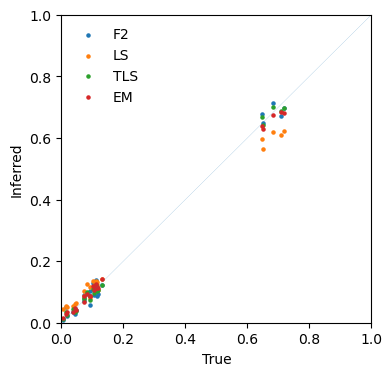

In [5]:
# plot results
plt.figure(figsize=(4,4))
plt.scatter(A,A_F2,s=5,label='F2')
plt.scatter(A,A_LS,s=5,label='LS')
plt.scatter(A,A_TLS,s=5,label='TLS')
plt.scatter(A,A_EM,s=5,label='EM')
plt.xlim([0,1])
plt.ylim([0,1])
plt.plot([0,1],linewidth=0.1)
plt.xlabel("True")
plt.ylabel("Inferred")
plt.legend(frameon=False)
plt.show()

In [27]:
#save_to_file
dfs=[]
for i in range(ND):
    for t in range(T):
        c=counts[i,:,t].astype(int)
        df=pd.DataFrame(zip(counts[i,:,t].astype(int),totcounts[i,:,t].astype(int)),columns=['counts','tot_counts'])
        df['time']=t
        df['dimension']=i
        df['lineage']=np.arange(len(df))
        dfs.append(df)
dfs=pd.concat(dfs)
dfs.to_csv('test.csv.gz',index=False,compression='gzip')
dfs.head()

,counts,tot_counts,time,dimension,lineage
0,17,300,0,0,0
1,10,300,0,0,1
2,11,300,0,0,2
3,25,300,0,0,3
4,58,300,0,0,4


In [32]:
# use command line
!influ -i test.csv.gz --method F2

[[0.71358041 0.02051982 0.10424672 0.05887196 0.10278109]
 [0.00892353 0.69580927 0.13782013 0.12289497 0.03455211]
 [0.09606596 0.10972844 0.64899434 0.02732121 0.11789005]
 [0.07207445 0.08864943 0.04150909 0.67017295 0.12759408]
 [0.08649747 0.09386005 0.05248211 0.09009131 0.67706906]]
